In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')
from typing import Tuple, List, Optional
import itertools
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("data.csv")
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
# Drop unnecessary columns
df.drop(['transaction_id', 'USER_ID'], axis=1, inplace=True, errors='ignore')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  7500 non-null   object 
 1   age                      7500 non-null   int64  
 2   gender                   7500 non-null   object 
 3   daily_screen_time_hours  7500 non-null   float64
 4   social_media_hours       7500 non-null   float64
 5   gaming_hours             7500 non-null   float64
 6   work_study_hours         7500 non-null   float64
 7   sleep_hours              7500 non-null   float64
 8   notifications_per_day    7500 non-null   int64  
 9   app_opens_per_day        7500 non-null   int64  
 10  weekend_screen_time      7500 non-null   float64
 11  stress_level             7500 non-null   object 
 12  academic_work_impact     7500 non-null   object 
 13  addiction_level          6681 non-null   object 
 14  addicted_label          

In [5]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [6]:
df.isnull().sum()

user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [7]:
df['addiction_level'].value_counts()

addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64

In [8]:
display(df['addiction_level'].unique())

array([nan, 'Mild', 'Moderate', 'Severe'], dtype=object)

In [9]:
df['addiction_level'] = df['addiction_level'].fillna('Not addicted')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  7500 non-null   object 
 1   age                      7500 non-null   int64  
 2   gender                   7500 non-null   object 
 3   daily_screen_time_hours  7500 non-null   float64
 4   social_media_hours       7500 non-null   float64
 5   gaming_hours             7500 non-null   float64
 6   work_study_hours         7500 non-null   float64
 7   sleep_hours              7500 non-null   float64
 8   notifications_per_day    7500 non-null   int64  
 9   app_opens_per_day        7500 non-null   int64  
 10  weekend_screen_time      7500 non-null   float64
 11  stress_level             7500 non-null   object 
 12  academic_work_impact     7500 non-null   object 
 13  addiction_level          7500 non-null   object 
 14  addicted_label          

In [11]:
df

,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Not addicted,0
1,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Not addicted,0
2,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,Not addicted,0
7497,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


# visualization

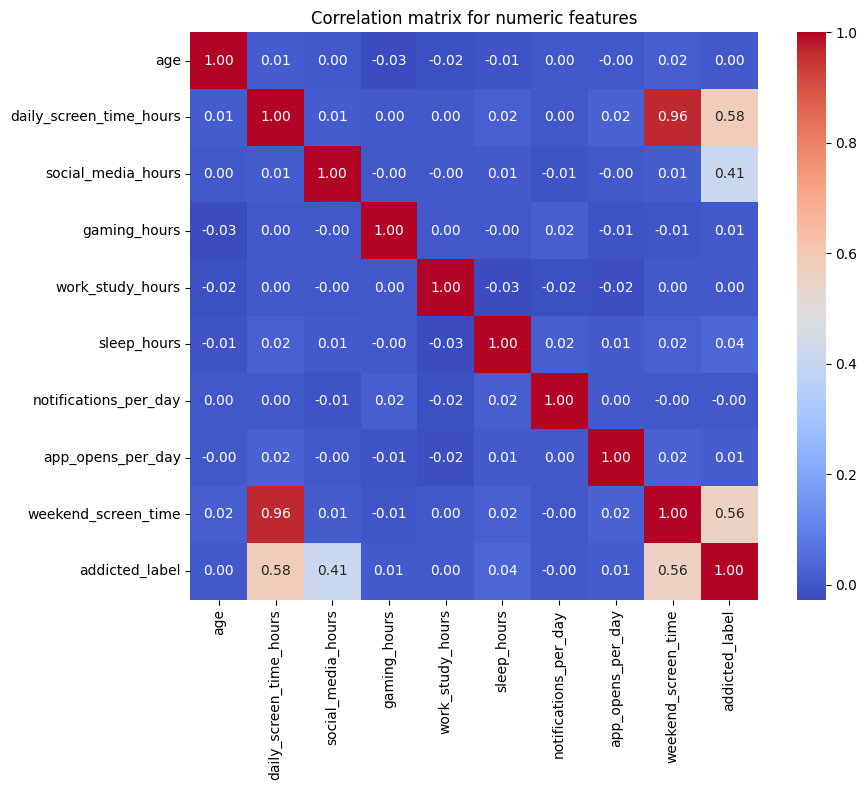

In [12]:
# Correlation matrix for numeric features
numeric_cols = df.select_dtypes(include=np.number).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation matrix for numeric features')
    plt.tight_layout()
    plt.show()

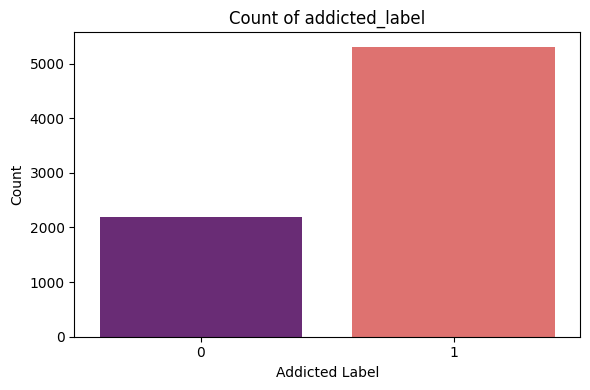

In [13]:
# addicted_label counts
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='addicted_label', palette='magma')
plt.title('Count of addicted_label')
plt.xlabel('Addicted Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [14]:
# Missing values overview
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    plt.figure(figsize=(8, 4))
    missing.sort_values(ascending=False).plot(kind='bar', color='steelblue')
    plt.title('Missing values by column')
    plt.ylabel('Number of missing values')
    plt.tight_layout()
    plt.show()


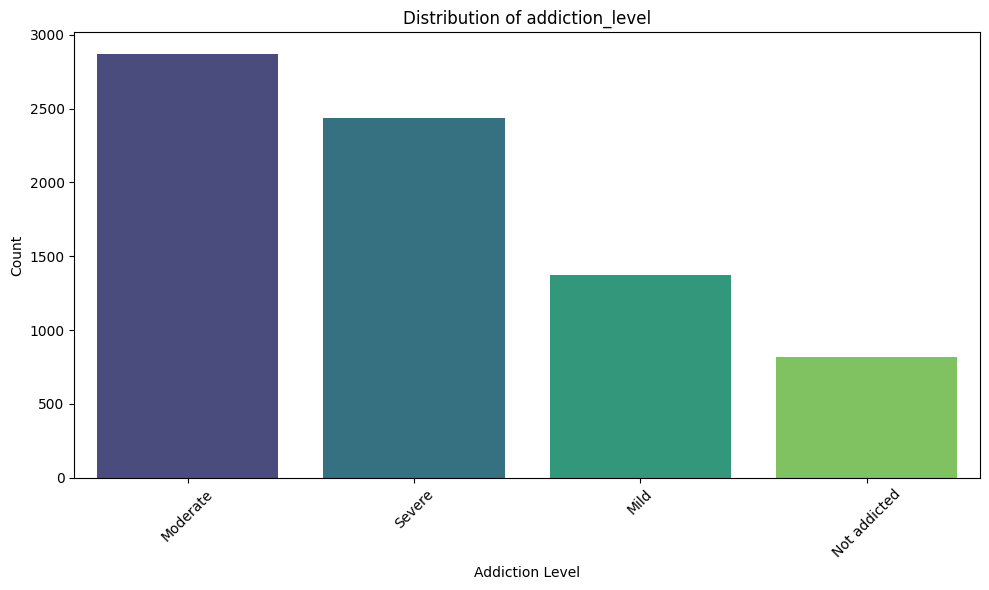

In [15]:
# Visualization for the dataset
df['addiction_level'] = df['addiction_level'].replace('nan', np.nan)

# Distribution of addiction levels
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='addiction_level', order=df['addiction_level'].value_counts().index, palette='viridis')
plt.title('Distribution of addiction_level')
plt.xlabel('Addiction Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# feature engineering

In [16]:
df["sleep_deficit"] = 8 - df["sleep_hours"]

df["screen_dependency"] = (
    df["daily_screen_time_hours"] +
    df["gaming_hours"] +
    df["social_media_hours"]
)

df["study_balance"] = df["work_study_hours"] / df["daily_screen_time_hours"]

In [17]:
df

,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,sleep_deficit,screen_dependency,study_balance
0,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Not addicted,0,0.45,6.13,1.408669
1,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Not addicted,0,0.34,11.14,0.872299
2,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,3.08,11.25,0.387789
3,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,-0.23,15.19,0.452107
4,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,1.79,19.30,0.529116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1,2.19,14.73,0.354315
7496,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,Not addicted,0,-0.47,10.76,1.040564
7497,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1,-0.17,14.69,0.116116
7498,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1,1.81,10.40,0.530892


In [18]:
df['academic_work_impact'].unique()

array(['Yes', 'No'], dtype=object)

In [19]:
stress_map = {'Low':0, 'Medium':1, 'High':2}
df['stress_level'] = df['stress_level'].map(stress_map)
df

,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,sleep_deficit,screen_dependency,study_balance
0,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,Yes,Not addicted,0,0.45,6.13,1.408669
1,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,Yes,Not addicted,0,0.34,11.14,0.872299
2,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,No,Mild,0,3.08,11.25,0.387789
3,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,Yes,Moderate,1,-0.23,15.19,0.452107
4,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,No,Severe,1,1.79,19.30,0.529116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,Yes,Moderate,1,2.19,14.73,0.354315
7496,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,No,Not addicted,0,-0.47,10.76,1.040564
7497,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,Yes,Severe,1,-0.17,14.69,0.116116
7498,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,Yes,Severe,1,1.81,10.40,0.530892


In [20]:
academic_map = {'No':0, 'Yes':1}
df['academic_work_impact'] = df['academic_work_impact'].map(academic_map)
df

,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,sleep_deficit,screen_dependency,study_balance
0,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,Not addicted,0,0.45,6.13,1.408669
1,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,Not addicted,0,0.34,11.14,0.872299
2,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,Mild,0,3.08,11.25,0.387789
3,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,Moderate,1,-0.23,15.19,0.452107
4,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,Severe,1,1.79,19.30,0.529116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,1,Moderate,1,2.19,14.73,0.354315
7496,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,0,Not addicted,0,-0.47,10.76,1.040564
7497,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,1,Severe,1,-0.17,14.69,0.116116
7498,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,1,Severe,1,1.81,10.40,0.530892


In [21]:
df['gender'].unique()

array(['Male', 'Other', 'Female'], dtype=object)

In [22]:
addiction_map = {'Not addicted':0, 'Mild':1, 'Moderate':2, 'Severe':3}
df['addiction_level'] = df['addiction_level'].map(addiction_map)
df

,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,sleep_deficit,screen_dependency,study_balance
0,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,0,0,0.45,6.13,1.408669
1,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,0,0,0.34,11.14,0.872299
2,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,1,0,3.08,11.25,0.387789
3,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,2,1,-0.23,15.19,0.452107
4,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,3,1,1.79,19.30,0.529116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,1,2,1,2.19,14.73,0.354315
7496,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,0,0,0,-0.47,10.76,1.040564
7497,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,1,3,1,-0.17,14.69,0.116116
7498,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,1,3,1,1.81,10.40,0.530892


In [23]:
gender_map = {'Male':0, 'Female':1, 'Other':2}
df['gender'] = df['gender'].map(gender_map)
df

,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,sleep_deficit,screen_dependency,study_balance
0,U00001,21,0,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,0,0,0.45,6.13,1.408669
1,U00002,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,0,0,0.34,11.14,0.872299
2,U00003,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,1,0,3.08,11.25,0.387789
3,U00004,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,2,1,-0.23,15.19,0.452107
4,U00005,25,0,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,3,1,1.79,19.30,0.529116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,U07496,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,1,2,1,2.19,14.73,0.354315
7496,U07497,35,0,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,0,0,0,-0.47,10.76,1.040564
7497,U07498,22,1,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,1,3,1,-0.17,14.69,0.116116
7498,U07499,23,0,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,1,3,1,1.81,10.40,0.530892


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  7500 non-null   object 
 1   age                      7500 non-null   int64  
 2   gender                   7500 non-null   int64  
 3   daily_screen_time_hours  7500 non-null   float64
 4   social_media_hours       7500 non-null   float64
 5   gaming_hours             7500 non-null   float64
 6   work_study_hours         7500 non-null   float64
 7   sleep_hours              7500 non-null   float64
 8   notifications_per_day    7500 non-null   int64  
 9   app_opens_per_day        7500 non-null   int64  
 10  weekend_screen_time      7500 non-null   float64
 11  stress_level             7500 non-null   int64  
 12  academic_work_impact     7500 non-null   int64  
 13  addiction_level          7500 non-null   int64  
 14  addicted_label          

In [25]:
df.drop(['addiction_level'], axis=1, inplace=True)

In [26]:
df.drop(['user_id'], axis=1, inplace=True, errors='ignore')

In [27]:
df

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label,sleep_deficit,screen_dependency,study_balance
0,21,0,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,0,0.45,6.13,1.408669
1,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,0,0.34,11.14,0.872299
2,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0,3.08,11.25,0.387789
3,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,1,-0.23,15.19,0.452107
4,25,0,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,1,1.79,19.30,0.529116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,1,1,2.19,14.73,0.354315
7496,35,0,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,0,0,-0.47,10.76,1.040564
7497,22,1,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,1,1,-0.17,14.69,0.116116
7498,23,0,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,1,1,1.81,10.40,0.530892


# Models

In [28]:
x = df.drop(['addicted_label'], axis=1)
y = df['addicted_label']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [30]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}


→ Training & Evaluating: Logistic Regression
   Train Accuracy    : 0.8985
   Test Accuracy     : 0.8927
   CV Mean Accuracy  : 0.8975 (± 0.0051)
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       456
           1       0.92      0.92      0.92      1044

    accuracy                           0.89      1500
   macro avg       0.87      0.87      0.87      1500
weighted avg       0.89      0.89      0.89      1500



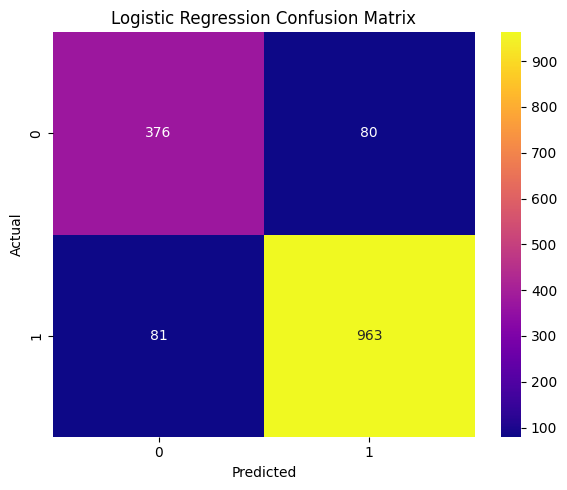


→ Training & Evaluating: Decision Tree
   Train Accuracy    : 1.0000
   Test Accuracy     : 0.9347
   CV Mean Accuracy  : 0.9325 (± 0.0066)
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       456
           1       0.95      0.95      0.95      1044

    accuracy                           0.93      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.93      0.93      0.93      1500



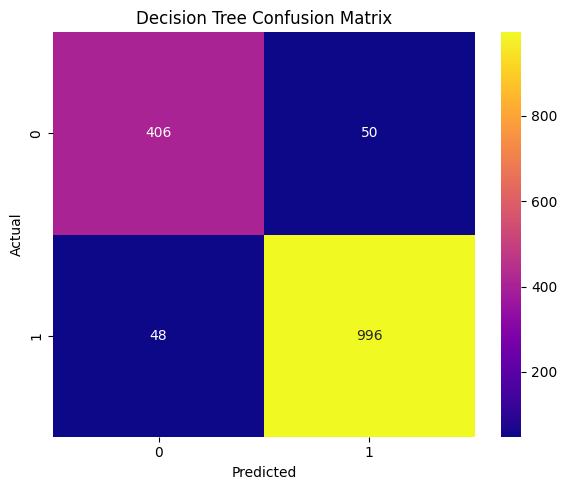


→ Training & Evaluating: KNN
   Train Accuracy    : 0.9322
   Test Accuracy     : 0.8860
   CV Mean Accuracy  : 0.8907 (± 0.0082)
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       456
           1       0.91      0.92      0.92      1044

    accuracy                           0.89      1500
   macro avg       0.87      0.86      0.86      1500
weighted avg       0.89      0.89      0.89      1500



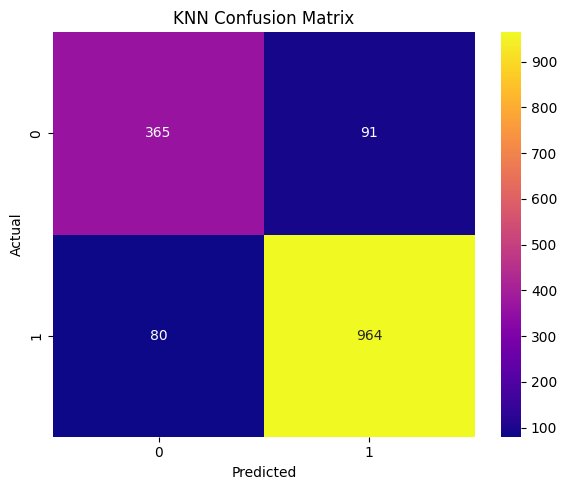


→ Training & Evaluating: Naive Bayes
   Train Accuracy    : 0.8638
   Test Accuracy     : 0.8480
   CV Mean Accuracy  : 0.8635 (± 0.0081)
              precision    recall  f1-score   support

           0       0.71      0.85      0.77       456
           1       0.93      0.85      0.89      1044

    accuracy                           0.85      1500
   macro avg       0.82      0.85      0.83      1500
weighted avg       0.86      0.85      0.85      1500



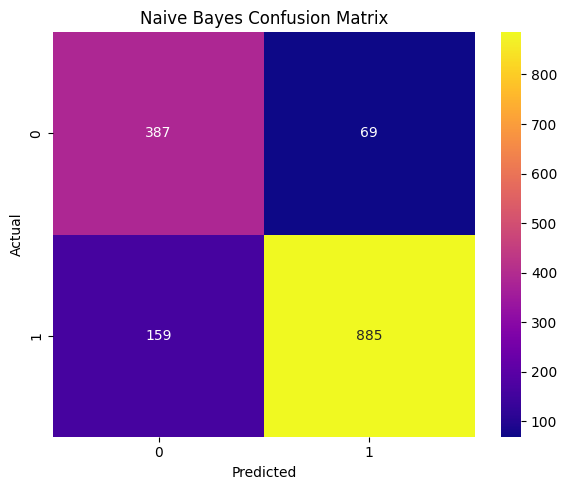


→ Training & Evaluating: SVM
   Train Accuracy    : 0.9325
   Test Accuracy     : 0.9180
   CV Mean Accuracy  : 0.9148 (± 0.0074)
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       456
           1       0.94      0.95      0.94      1044

    accuracy                           0.92      1500
   macro avg       0.91      0.90      0.90      1500
weighted avg       0.92      0.92      0.92      1500



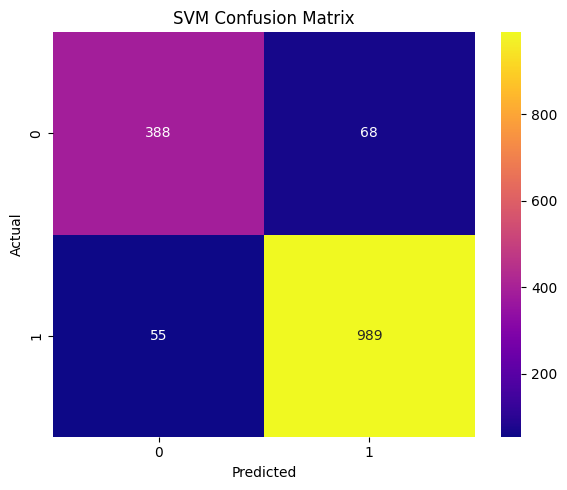


→ Training & Evaluating: Random Forest
   Train Accuracy    : 1.0000
   Test Accuracy     : 0.9273
   CV Mean Accuracy  : 0.9358 (± 0.0032)
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       456
           1       0.96      0.94      0.95      1044

    accuracy                           0.93      1500
   macro avg       0.91      0.92      0.92      1500
weighted avg       0.93      0.93      0.93      1500



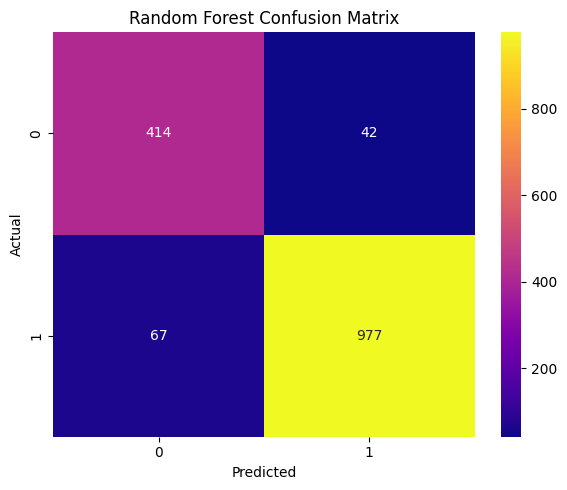


→ Training & Evaluating: XGBoost
   Train Accuracy    : 1.0000
   Test Accuracy     : 0.9293
   CV Mean Accuracy  : 0.9313 (± 0.0060)
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       456
           1       0.95      0.95      0.95      1044

    accuracy                           0.93      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.93      0.93      0.93      1500



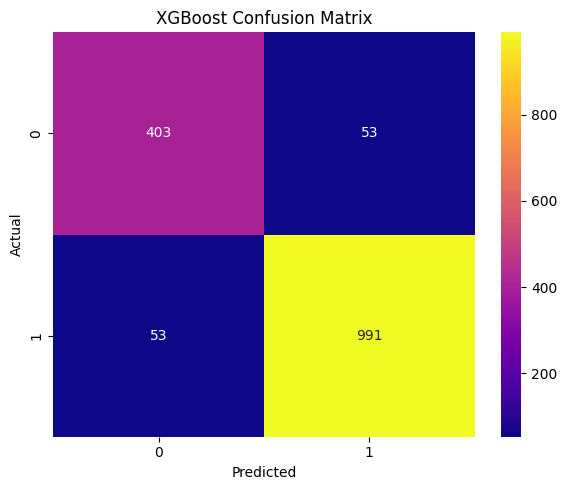

In [32]:
from sklearn.model_selection import cross_validate

result = {}
train_scores = {}
summary = {}

for name, model in models.items():
    print(f"\n→ Training & Evaluating: {name}")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_scores[name] = train_acc

    cv_result = cross_validate(model, X_train, y_train, cv=5, scoring='accuracy', return_train_score=False)
    cv_mean = cv_result['test_score'].mean()
    cv_std = cv_result['test_score'].std()

    result[name] = {
        'test_accuracy': test_acc,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'model': model
    }

    print(f"   Train Accuracy    : {train_acc:.4f}")
    print(f"   Test Accuracy     : {test_acc:.4f}")
    print(f"   CV Mean Accuracy  : {cv_mean:.4f} (± {cv_std:.4f})")
    print(classification_report(y_test, y_test_pred))

    # Plot confusion matrix heatmap for each model
    cm = confusion_matrix(y_test, y_test_pred)
    class_names = [str(c) for c in model.classes_]
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='plasma', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


→ Generating Learning Curve for: Logistic Regression


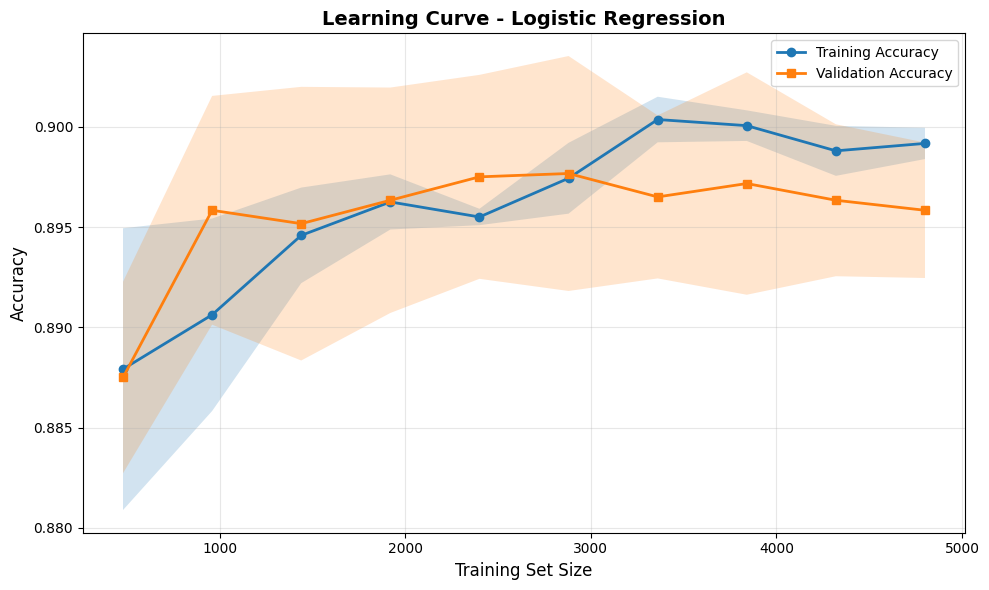


→ Generating Learning Curve for: Decision Tree


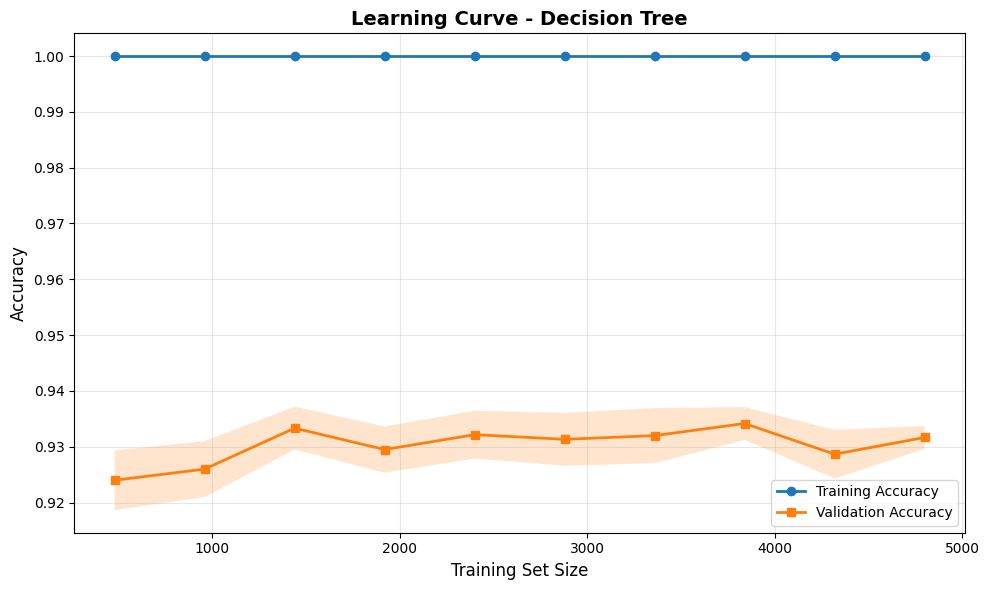


→ Generating Learning Curve for: KNN


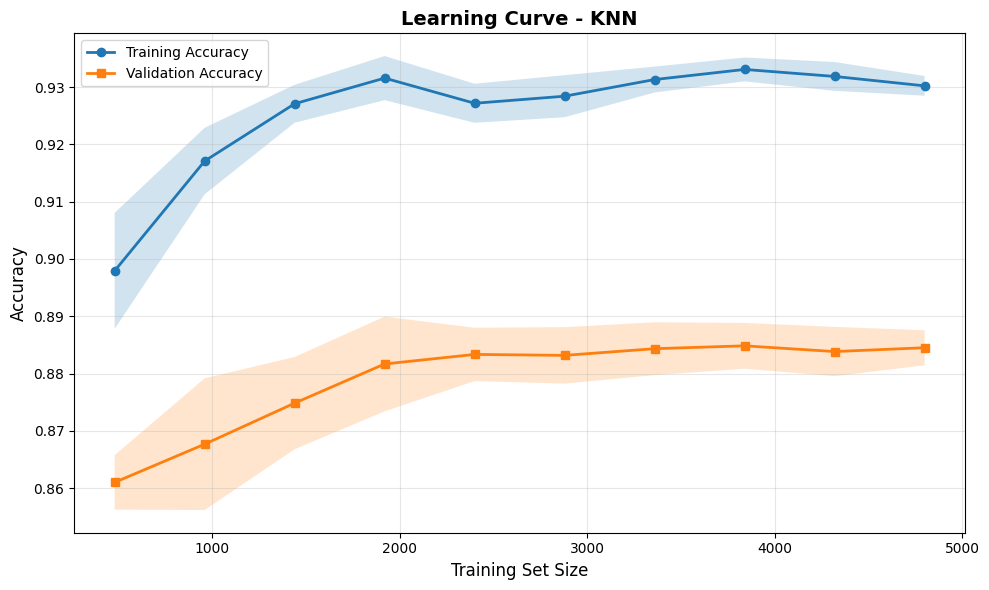


→ Generating Learning Curve for: Naive Bayes


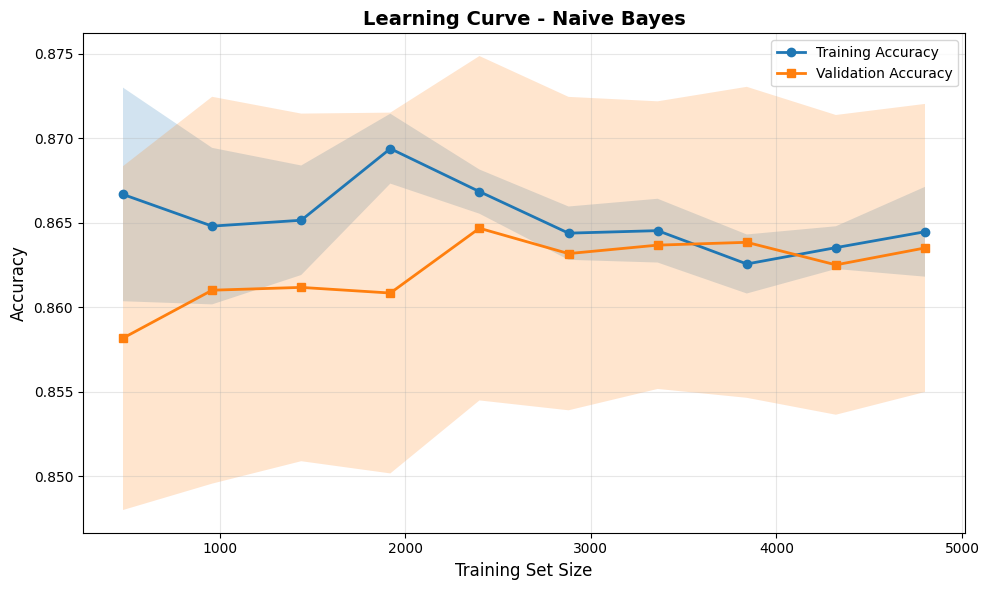


→ Generating Learning Curve for: SVM


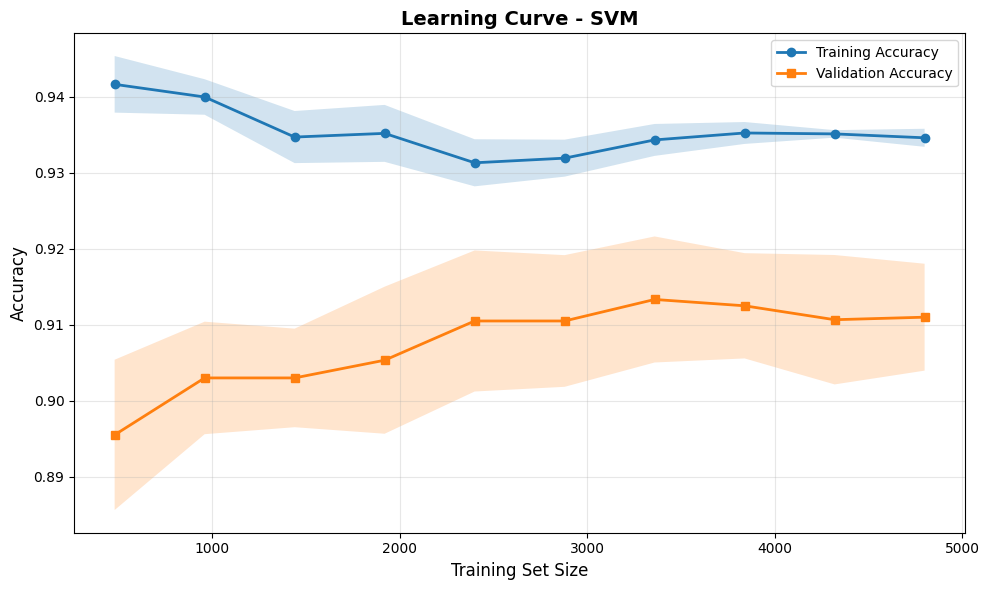


→ Generating Learning Curve for: Random Forest


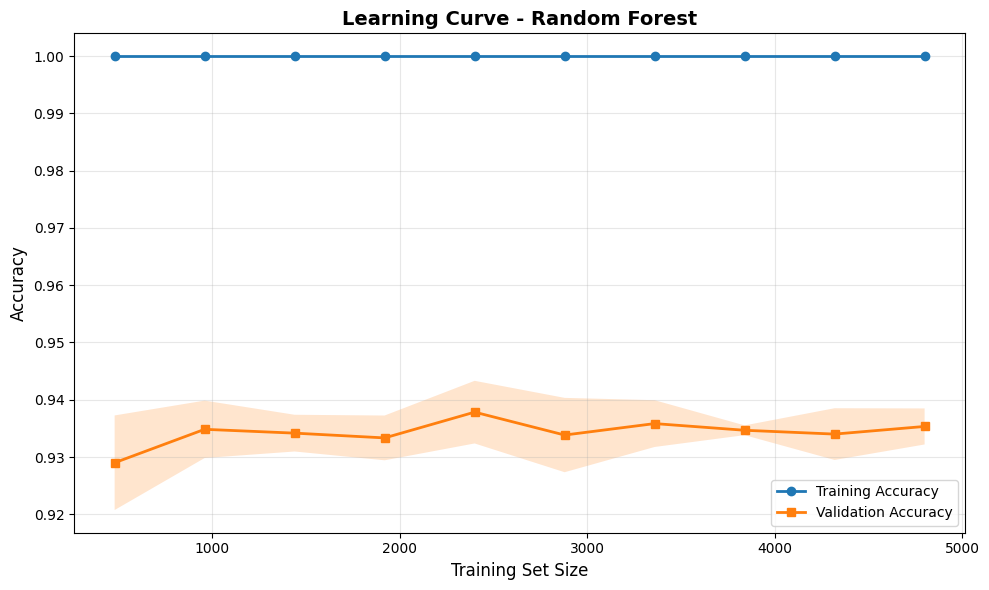


→ Generating Learning Curve for: XGBoost


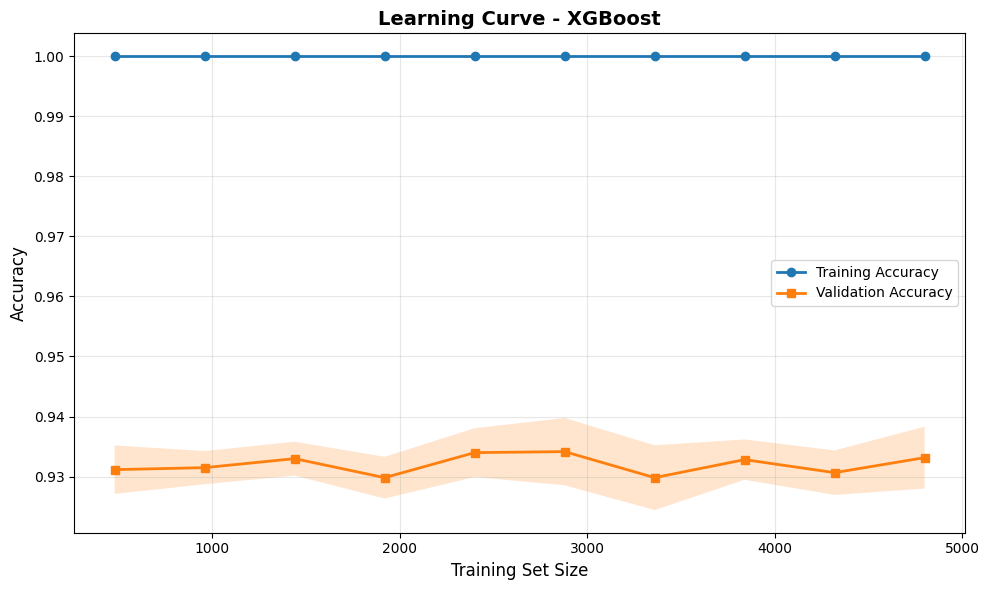

In [33]:
# Learning Curve for Each Model
from sklearn.model_selection import learning_curve, KFold

# Define KFold cross-validator
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Generate learning curves for each model
for name, model_info in result.items():
    print(f"\n→ Generating Learning Curve for: {name}")

    train_sizes, train_scores, test_scores = learning_curve(
        model_info['model'],
        X_train,
        y_train,
        cv=kfold,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy", linewidth=2)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

    plt.plot(train_sizes, test_mean, marker='s', label="Validation Accuracy", linewidth=2)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

    plt.xlabel("Training Set Size", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.title(f"Learning Curve - {name}", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Model summary and save best model

In [34]:
# Create a summary table for model performance
summary_df = pd.DataFrame([
    {
        "Model": name,
        "Test Accuracy": info["test_accuracy"],
        "CV Mean Accuracy": info["cv_mean"],
        "CV Std Dev": info["cv_std"]
    }
    for name, info in result.items()
]).sort_values(by="Test Accuracy", ascending=False)

display(summary_df)

best_model_name = summary_df.iloc[0]["Model"]
best_model_info = result[best_model_name]
best_model = best_model_info["model"]
feature_names = x.columns.tolist()

print(f"Best model: {best_model_name}")
print(f" -> Test Accuracy: {best_model_info['test_accuracy']:.4f}")
print(f" -> CV Mean Accuracy: {best_model_info['cv_mean']:.4f} (± {best_model_info['cv_std']:.4f})")

# Save the scaler and best model together
joblib.dump(
    {"model": best_model, "scaler": scaler, "feature_names": feature_names},
    "best_addiction_model.joblib"
)
print("Saved best model and scaler to best_addiction_model.joblib")

,Model,Test Accuracy,CV Mean Accuracy,CV Std Dev
1,Decision Tree,0.934667,0.932500,0.006604
6,XGBoost,0.929333,0.931333,0.006000
5,Random Forest,0.927333,0.935833,0.003249
4,SVM,0.918000,0.914833,0.007367
0,Logistic Regression,0.892667,0.897500,0.005083
2,KNN,0.886000,0.890667,0.008239
3,Naive Bayes,0.848000,0.863500,0.008052


Best model: Decision Tree
 -> Test Accuracy: 0.9347
 -> CV Mean Accuracy: 0.9325 (± 0.0066)
Saved best model and scaler to best_addiction_model.joblib


# Load saved model and predict

In [35]:

import joblib

loaded = joblib.load("best_addiction_model.joblib")
loaded_model = loaded["model"]
loaded_scaler = loaded["scaler"]
loaded_feature_names = loaded["feature_names"]


def predict_addiction(input_data: dict):
    """
    Takes a dict of raw feature values (before engineered features),
    engineers the same features used in training, scales them with the
    saved scaler, and returns the predicted addicted_label with probabilities.
    """
    data = input_data.copy()
    data["sleep_deficit"] = 8 - data["sleep_hours"]
    data["screen_dependency"] = (
        data["daily_screen_time_hours"] + data["gaming_hours"] + data["social_media_hours"]
    )
    data["study_balance"] = (
        data["work_study_hours"] / data["daily_screen_time_hours"]
        if data["daily_screen_time_hours"] != 0 else 0
    )

    input_df = pd.DataFrame([data]).reindex(columns=loaded_feature_names, fill_value=0)
    input_scaled = loaded_scaler.transform(input_df)

    pred = loaded_model.predict(input_scaled)[0]
    proba = loaded_model.predict_proba(input_scaled)[0] if hasattr(loaded_model, "predict_proba") else None

    return {"predicted_label": int(pred), "probabilities": proba}


In [36]:
# Try the loaded model on two different sample profiles
test_case_low_usage = {
    "sleep_hours": 7.0,
    "daily_screen_time_hours": 3.0,
    "gaming_hours": 0.5,
    "social_media_hours": 1.0,
    "work_study_hours": 6.0,
    "stress_level": 0,
    "academic_work_impact": 0,
    "gender": 0,
    "age": 22,
    "notifications_per_day": 10,
    "app_opens_per_day": 15,
    "weekend_screen_time": 3.0,
}

test_case_heavy_usage = {
    "sleep_hours": 4.0,
    "daily_screen_time_hours": 10.0,
    "gaming_hours": 4.0,
    "social_media_hours": 5.0,
    "work_study_hours": 1.0,
    "stress_level": 2,
    "academic_work_impact": 1,
    "gender": 1,
    "age": 19,
    "notifications_per_day": 120,
    "app_opens_per_day": 90,
    "weekend_screen_time": 12.0,
}

for name, case in [("Low usage", test_case_low_usage), ("Heavy usage", test_case_heavy_usage)]:
    result = predict_addiction(case)
    print(f"{name} -> {result}")


Low usage -> {'predicted_label': 0, 'probabilities': array([1., 0.])}
Heavy usage -> {'predicted_label': 1, 'probabilities': array([0., 1.])}


# Test new sample data

In [37]:
sample_input = {
    "sleep_hours": 6.0,
    "daily_screen_time_hours": 5.0,
    "gaming_hours": 2.0,
    "social_media_hours": 2.0,
    "work_study_hours": 3.0,
    "stress_level": 1,
    "academic_work_impact": 0,
    "gender": 0,
    "age": 20,
    "notifications_per_day": 30,
    "app_opens_per_day": 25,
    "weekend_screen_time": 5.0,
}

sample_input["sleep_deficit"] = 8 - sample_input["sleep_hours"]
sample_input["screen_dependency"] = (
    sample_input["daily_screen_time_hours"]
    + sample_input["gaming_hours"]
    + sample_input["social_media_hours"]
)
sample_input["study_balance"] = (
    sample_input["work_study_hours"]
    / sample_input["daily_screen_time_hours"]
    if sample_input["daily_screen_time_hours"] != 0
    else 0
)

sample_df = pd.DataFrame([sample_input])
sample_df = sample_df.reindex(columns=feature_names, fill_value=0)

sample_scaled = scaler.transform(sample_df)

pred = best_model.predict(sample_scaled)[0]
prediction_proba = None
if hasattr(best_model, "predict_proba"):
    prediction_proba = best_model.predict_proba(sample_scaled)[0]

print("Sample input:")
display(sample_df)
print("Predicted addicted_label:", pred)
if prediction_proba is not None:
    print("Prediction probabilities:", prediction_proba)

Sample input:


,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,sleep_deficit,screen_dependency,study_balance
0,20,0,5.0,2.0,2.0,3.0,6.0,30,25,5.0,1,0,2.0,9.0,0.6


Predicted addicted_label: 0
Prediction probabilities: [1. 0.]
